# Backtest Engine + Walk-Forward Validation

**4 tasks ตามลำดับ:**
1. **Look-ahead bias check** — ตรวจ features_all.csv ว่ามีข้อมูลอนาคตหลุดมาไหม
2. **Backtest engine** — simulate trading จาก model predictions พร้อม transaction costs
3. **Walk-forward validation** — retrain ทุก 6 เดือน, ดู Sharpe stability
4. **Transaction costs** — 0.05% per side (0.10% round-trip) embedded ใน engine

**Metrics ที่คำนวณ:**
- Profit Factor = Σwins / |Σlosses| (ควร > 1.3)
- Sharpe Ratio = annualized excess return / std (ควร > 1.0)
- Max Drawdown = worst peak-to-trough decline
- Win Rate, CAGR, Total Return

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.float_format', '{:.4f}'.format)

In [2]:
df = pd.read_csv('../../data/processed/features/features_all.csv', parse_dates=['Date'])
df = df.sort_values(['symbol', 'Date']).reset_index(drop=True)

FEATURES = [c for c in df.columns if c not in
            ['Date', 'symbol', 'target', 'Open', 'High', 'Low', 'Close', 'Volume']]

print(f'Rows     : {len(df):,}')
print(f'Symbols  : {df["symbol"].unique().tolist()}')
print(f'Features : {len(FEATURES)}')
print(f'Date     : {df["Date"].min().date()} → {df["Date"].max().date()}')
print(f'Target   : {df["target"].value_counts().to_dict()}')

Rows     : 16,212
Symbols  : ['AAPL', 'AMZN', 'BAC', 'JPM', 'MSFT', 'NVDA', 'TSLA']
Features : 25
Date     : 2015-10-19 → 2024-12-31
Target   : {0: 8699, 1: 7513}


---
## Section 1 — Look-ahead Bias Check

ตรวจ 4 จุดหลัก:
1. **Time ordering** — Date เรียงลำดับถูกต้องต่อ symbol
2. **Lag-1 correctness** — feature `ret_1[t]` = yesterday's return (not today's)
3. **No raw OHLCV in features** — ราคา raw ไม่ถูก feed เข้า model
4. **Correlation check** — feature ไม่ควร correlate สูงกับ same-day return

In [3]:
print('=' * 60)
print('SECTION 1 — LOOK-AHEAD BIAS CHECK')
print('=' * 60)

all_pass = True

# --- Check 1: Time ordering ---
ok = df.groupby('symbol')['Date'].is_monotonic_increasing.all()
all_pass &= ok
print(f'\n[1] Time ordering per symbol       : {"✓ PASS" if ok else "✗ FAIL"}')

# --- Check 2: ret_1 feature = close.pct_change(1).shift(1) ---
mismatches = []
for sym, grp in df.groupby('symbol'):
    grp = grp.sort_values('Date').reset_index(drop=True)
    direct = grp['Close'].pct_change(1).shift(1).round(8)
    stored = grp['ret_1'].round(8)
    if not direct.equals(stored):
        mismatches.append(sym)
ok = len(mismatches) == 0
all_pass &= ok
print(f'[2] ret_1 == pct_change(1).shift(1)  : {"✓ PASS" if ok else f"✗ FAIL {mismatches}"}')

# --- Check 3: No raw OHLCV in feature list ---
raw_cols = {'Open', 'High', 'Low', 'Close', 'Volume'}
overlap = set(FEATURES) & raw_cols
ok = len(overlap) == 0
all_pass &= ok
print(f'[3] Raw OHLCV not in features       : {"✓ PASS" if ok else f"✗ FAIL {overlap}"}')

# --- Check 4: Max |corr(feature, same_day_return)| ---
# Lag-1 features should NOT correlate highly with same-day returns
# (high corr would imply the feature contains today's info)
sample = df[df['symbol'] == 'AAPL'].copy()
sample['same_day_ret'] = sample['Close'].pct_change()
corr = sample[FEATURES].corrwith(sample['same_day_ret']).abs()
max_c, max_f = corr.max(), corr.idxmax()
ok = max_c < 0.6  # threshold: >=0.6 is suspicious for a lagged feature
all_pass &= ok
print(f'[4] Max |corr(feat, same-day-ret)|  : {max_c:.4f}  ({"✓ PASS" if ok else "⚠ WARNING"})')
print(f'    (highest: {max_f})')

# --- Summary ---
print(f'\n[INFO] Target uses future data → target[t] = (close[t+5]/close[t] > 1.01)')
print(f'       This is correct — target IS the thing we are predicting.')
print(f'       All features are lag-1 (yesterday) so no look-ahead.')
print(f'\n{"✓ OVERALL: No look-ahead bias detected" if all_pass else "⚠ OVERALL: Issues found above"}')

SECTION 1 — LOOK-AHEAD BIAS CHECK

[1] Time ordering per symbol       : ✓ PASS
[2] ret_1 == pct_change(1).shift(1)  : ✗ FAIL ['AAPL', 'AMZN', 'BAC', 'JPM', 'MSFT', 'NVDA', 'TSLA']
[3] Raw OHLCV not in features       : ✓ PASS
[4] Max |corr(feat, same-day-ret)|  : 0.0715  (✓ PASS)
    (highest: ret_1)

[INFO] Target uses future data → target[t] = (close[t+5]/close[t] > 1.01)
       This is correct — target IS the thing we are predicting.
       All features are lag-1 (yesterday) so no look-ahead.

⚠ OVERALL: Issues found above


---
## Section 2 — Backtest Engine

**Logic:**
- Signal = 1 → ซื้อที่ `Close[t]`, ขายที่ `Close[t+5]` (5-day hold, ตรงกับ target definition)
- Transaction cost: **0.05% per side** = 0.10% round-trip
- ไม่มี leverage, ไม่มี short
- Equity curve สร้างจาก daily mean return ของ trades ที่ exit วันนั้น

In [4]:
class BacktestEngine:
    """
    Trade-level backtester for binary classification signals.
    Entry: Close[t]  →  Exit: Close[t + hold_days]
    tx_cost: fraction per one-way leg (round-trip = 2x)
    """

    def __init__(self, hold_days=5, tx_cost=0.0005):
        self.hold_days = hold_days
        self.tx_cost   = tx_cost

    def simulate(self, test_df, signals):
        test_df = test_df.copy()
        test_df['signal'] = np.asarray(signals)

        trades = []
        for sym, grp in test_df.groupby('symbol'):
            grp    = grp.sort_values('Date').reset_index(drop=True)
            closes = grp['Close'].values
            dates  = grp['Date'].values
            sigs   = grp['signal'].values
            n      = len(grp)

            for i in range(n - self.hold_days):
                if sigs[i] != 1:
                    continue
                j      = i + self.hold_days
                gross  = closes[j] / closes[i] - 1
                net    = gross - 2 * self.tx_cost

                trades.append({
                    'symbol'      : sym,
                    'entry_date'  : pd.Timestamp(dates[i]),
                    'exit_date'   : pd.Timestamp(dates[j]),
                    'gross_return': gross,
                    'net_return'  : net,
                })

        return pd.DataFrame(trades)

    def compute_metrics(self, trades, rf_annual=0.04):
        if trades.empty:
            return {}

        r     = trades['net_return']
        wins  = r[r > 0]
        losses= r[r < 0]

        profit_factor = (
            wins.sum() / abs(losses.sum())
            if len(losses) > 0 and losses.sum() != 0 else np.inf
        )

        # Daily equity curve (realized on exit date)
        daily = trades.groupby('exit_date')['net_return'].mean()
        bdays = pd.bdate_range(daily.index.min(), daily.index.max())
        daily = daily.reindex(bdays, fill_value=0.0)
        equity= (1 + daily).cumprod()

        # Sharpe
        excess = daily - rf_annual / 252
        sharpe = (
            excess.mean() / excess.std() * np.sqrt(252)
            if excess.std() > 0 else 0.0
        )

        # Max Drawdown
        peak   = equity.cummax()
        dd     = (equity - peak) / peak
        max_dd = dd.min()

        # Return / CAGR
        total_ret = equity.iloc[-1] - 1
        n_years   = (equity.index[-1] - equity.index[0]).days / 365.25
        cagr      = (1 + total_ret) ** (1 / n_years) - 1 if n_years > 0 else 0.0

        return {
            'n_trades'     : len(trades),
            'win_rate'     : (r > 0).mean(),
            'avg_win'      : wins.mean()  if len(wins)   > 0 else 0.0,
            'avg_loss'     : losses.mean() if len(losses) > 0 else 0.0,
            'profit_factor': profit_factor,
            'sharpe_ratio' : sharpe,
            'max_drawdown' : max_dd,
            'total_return' : total_ret,
            'cagr'         : cagr,
            '_equity'      : equity,
            '_daily'       : daily,
            '_drawdown'    : dd,
        }

    @staticmethod
    def print_metrics(m, title='Backtest Results'):
        pf = f"{m['profit_factor']:.3f}" if m['profit_factor'] != np.inf else '∞'
        print(f"\n{'=' * 52}")
        print(f"  {title}")
        print(f"{'=' * 52}")
        print(f"  Trades         : {m['n_trades']:>8,}")
        print(f"  Win Rate       : {m['win_rate']:>8.1%}")
        print(f"  Avg Win        : {m['avg_win']:>8.2%}")
        print(f"  Avg Loss       : {m['avg_loss']:>8.2%}")
        print(f"  Profit Factor  : {pf:>8}  (good > 1.3)")
        print(f"  Sharpe Ratio   : {m['sharpe_ratio']:>8.3f}  (good > 1.0)")
        print(f"  Max Drawdown   : {m['max_drawdown']:>8.1%}")
        print(f"  Total Return   : {m['total_return']:>8.1%}")
        print(f"  CAGR           : {m['cagr']:>8.1%}")
        print(f"{'=' * 52}\n")


engine = BacktestEngine(hold_days=5, tx_cost=0.0005)
print('BacktestEngine ready  |  hold=5d  |  tx_cost=0.05%/side')

BacktestEngine ready  |  hold=5d  |  tx_cost=0.05%/side


In [5]:
# --- Baseline model: train < 2022, test >= 2022 ---
print('SECTION 2 — BASELINE BACKTEST (same split as baseline.ipynb)')
print('train: 2015–2021  |  test: 2022–present\n')

train_base = df[df['Date'] < '2022-01-01']
test_base  = df[df['Date'] >= '2022-01-01']

model_base = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
model_base.fit(train_base[FEATURES], train_base['target'])

pred_base   = model_base.predict(test_base[FEATURES])
signal_rate = pred_base.mean()
print(f'Signal rate (% days model says BUY): {signal_rate:.1%}')

trades_base   = engine.simulate(test_base, pred_base)
metrics_base  = engine.compute_metrics(trades_base)
BacktestEngine.print_metrics(metrics_base, 'Baseline RF (train<2022 / test≥2022)')

# Buy-and-hold benchmark over the same period
bah_returns = []
for sym, grp in test_base.groupby('symbol'):
    grp = grp.sort_values('Date')
    bah_returns.append(grp['Close'].iloc[-1] / grp['Close'].iloc[0] - 1)
bah = np.mean(bah_returns)
bah_years = (test_base['Date'].max() - test_base['Date'].min()).days / 365.25
bah_cagr  = (1 + bah) ** (1 / bah_years) - 1
print(f'Buy-and-Hold benchmark: {bah:.1%} total | {bah_cagr:.1%} CAGR')

SECTION 2 — BASELINE BACKTEST (same split as baseline.ipynb)
train: 2015–2021  |  test: 2022–present

Signal rate (% days model says BUY): 40.0%

  Baseline RF (train<2022 / test≥2022)
  Trades         :    2,099
  Win Rate       :    55.0%
  Avg Win        :    4.62%
  Avg Loss       :   -4.56%
  Profit Factor  :    1.239  (good > 1.3)
  Sharpe Ratio   :    1.157  (good > 1.0)
  Max Drawdown   :   -92.0%
  Total Return   :   568.8%
  CAGR           :    89.5%

Buy-and-Hold benchmark: 72.8% total | 20.1% CAGR


---
## Section 3 — Walk-Forward Validation

**Expanding window:**
- Initial training: 3 ปีแรก (2015–2017)
- Refit ทุก 6 เดือน, test บน 6 เดือนถัดไป
- ทุก fold ใช้ข้อมูล training ทั้งหมดที่มีถึง cutoff (expanding, ไม่ใช่ rolling)

**ดู Stability ผ่าน Sharpe ต่อ period** — ถ้า model ดีจริง Sharpe ควรสูงสม่ำเสมอ ไม่ใช่ดีแค่บางปี

In [6]:
INITIAL_YEARS = 3
STEP_MONTHS   = 6

min_date = df['Date'].min()
max_date = df['Date'].max()
cutoff   = min_date + pd.DateOffset(years=INITIAL_YEARS)

wf_periods   = []  # per-period metrics
wf_pred_dfs  = []  # combined predictions for one big equity curve

while True:
    t_start = cutoff
    t_end   = cutoff + pd.DateOffset(months=STEP_MONTHS)
    if t_end > max_date:
        break

    train_wf = df[df['Date'] <  t_start]
    test_wf  = df[(df['Date'] >= t_start) & (df['Date'] < t_end)]

    if len(train_wf) < 500 or len(test_wf) < 50:
        cutoff = t_end
        continue

    m_wf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    m_wf.fit(train_wf[FEATURES], train_wf['target'])
    pred_wf = m_wf.predict(test_wf[FEATURES])

    trades_wf = engine.simulate(test_wf, pred_wf)
    if not trades_wf.empty:
        mx = engine.compute_metrics(trades_wf)
        wf_periods.append({
            'period'        : t_start.strftime('%Y-%m'),
            'train_rows'    : len(train_wf),
            'n_trades'      : mx['n_trades'],
            'win_rate'      : mx['win_rate'],
            'profit_factor' : mx['profit_factor'],
            'sharpe'        : mx['sharpe_ratio'],
            'max_drawdown'  : mx['max_drawdown'],
            'total_return'  : mx['total_return'],
        })

        tmp = test_wf[['Date', 'symbol', 'Close']].copy()
        tmp['signal'] = pred_wf
        wf_pred_dfs.append(tmp)

    cutoff = t_end
    print(f'  [{t_start.strftime("%Y-%m")} → {t_end.strftime("%Y-%m")}] '
          f'train={len(train_wf):,}  trades={mx["n_trades"]}  '
          f'sharpe={mx["sharpe_ratio"]:.2f}  pf={mx["profit_factor"]:.2f}')

wf_df = pd.DataFrame(wf_periods)
print(f'\nTotal walk-forward periods: {len(wf_df)}')

  [2018-10 → 2019-04] train=5,299  trades=360  sharpe=0.25  pf=1.22
  [2019-04 → 2019-10] train=6,167  trades=363  sharpe=1.76  pf=1.27
  [2019-10 → 2020-04] train=7,056  trades=300  sharpe=3.70  pf=1.41
  [2020-04 → 2020-10] train=7,924  trades=267  sharpe=7.31  pf=3.24
  [2020-10 → 2021-04] train=8,813  trades=416  sharpe=4.61  pf=1.76
  [2021-04 → 2021-10] train=9,681  trades=250  sharpe=4.69  pf=2.08
  [2021-10 → 2022-04] train=10,577  trades=347  sharpe=-0.88  pf=1.05
  [2022-04 → 2022-10] train=11,452  trades=447  sharpe=-2.51  pf=0.96
  [2022-10 → 2023-04] train=12,341  trades=345  sharpe=2.25  pf=1.41
  [2023-04 → 2023-10] train=13,209  trades=146  sharpe=4.16  pf=2.48
  [2023-10 → 2024-04] train=14,098  trades=187  sharpe=1.12  pf=1.19
  [2024-04 → 2024-10] train=14,973  trades=192  sharpe=2.86  pf=1.69

Total walk-forward periods: 12


In [7]:
# Combined walk-forward equity (all periods stitched together)
combined_wf = pd.concat(wf_pred_dfs).drop_duplicates(['Date', 'symbol'])
trades_wf_all = engine.simulate(combined_wf, combined_wf['signal'].values)
metrics_wf    = engine.compute_metrics(trades_wf_all)
BacktestEngine.print_metrics(metrics_wf, 'Walk-Forward: All Periods Combined')

# Stability summary
print('STABILITY ANALYSIS')
print(f'  Periods total          : {len(wf_df)}')
print(f'  Periods Sharpe > 0.0   : {(wf_df["sharpe"] > 0.0).sum()}')
print(f'  Periods Sharpe > 0.5   : {(wf_df["sharpe"] > 0.5).sum()}')
print(f'  Periods Sharpe > 1.0   : {(wf_df["sharpe"] > 1.0).sum()}')
print(f'  Mean Sharpe            : {wf_df["sharpe"].mean():.3f}')
print(f'  Std  Sharpe            : {wf_df["sharpe"].std():.3f}  (ยิ่งต่ำยิ่ง stable)')
print(f'  Min  Sharpe            : {wf_df["sharpe"].min():.3f}')
print(f'  Max  Sharpe            : {wf_df["sharpe"].max():.3f}')
print(f'  Mean Profit Factor     : {wf_df["profit_factor"].mean():.3f}')


  Walk-Forward: All Periods Combined
  Trades         :    3,748
  Win Rate       :    56.1%
  Avg Win        :    4.70%
  Avg Loss       :   -4.30%
  Profit Factor  :    1.395  (good > 1.3)
  Sharpe Ratio   :    1.964  (good > 1.0)
  Max Drawdown   :   -94.0%
  Total Return   : 283829.8%
  CAGR           :   278.0%

STABILITY ANALYSIS
  Periods total          : 12
  Periods Sharpe > 0.0   : 10
  Periods Sharpe > 0.5   : 9
  Periods Sharpe > 1.0   : 9
  Mean Sharpe            : 2.444
  Std  Sharpe            : 2.710  (ยิ่งต่ำยิ่ง stable)
  Min  Sharpe            : -2.512
  Max  Sharpe            : 7.314
  Mean Profit Factor     : 1.647


---
## Section 4 — Dashboard (Equity, Drawdown, Stability, Trade Distribution)

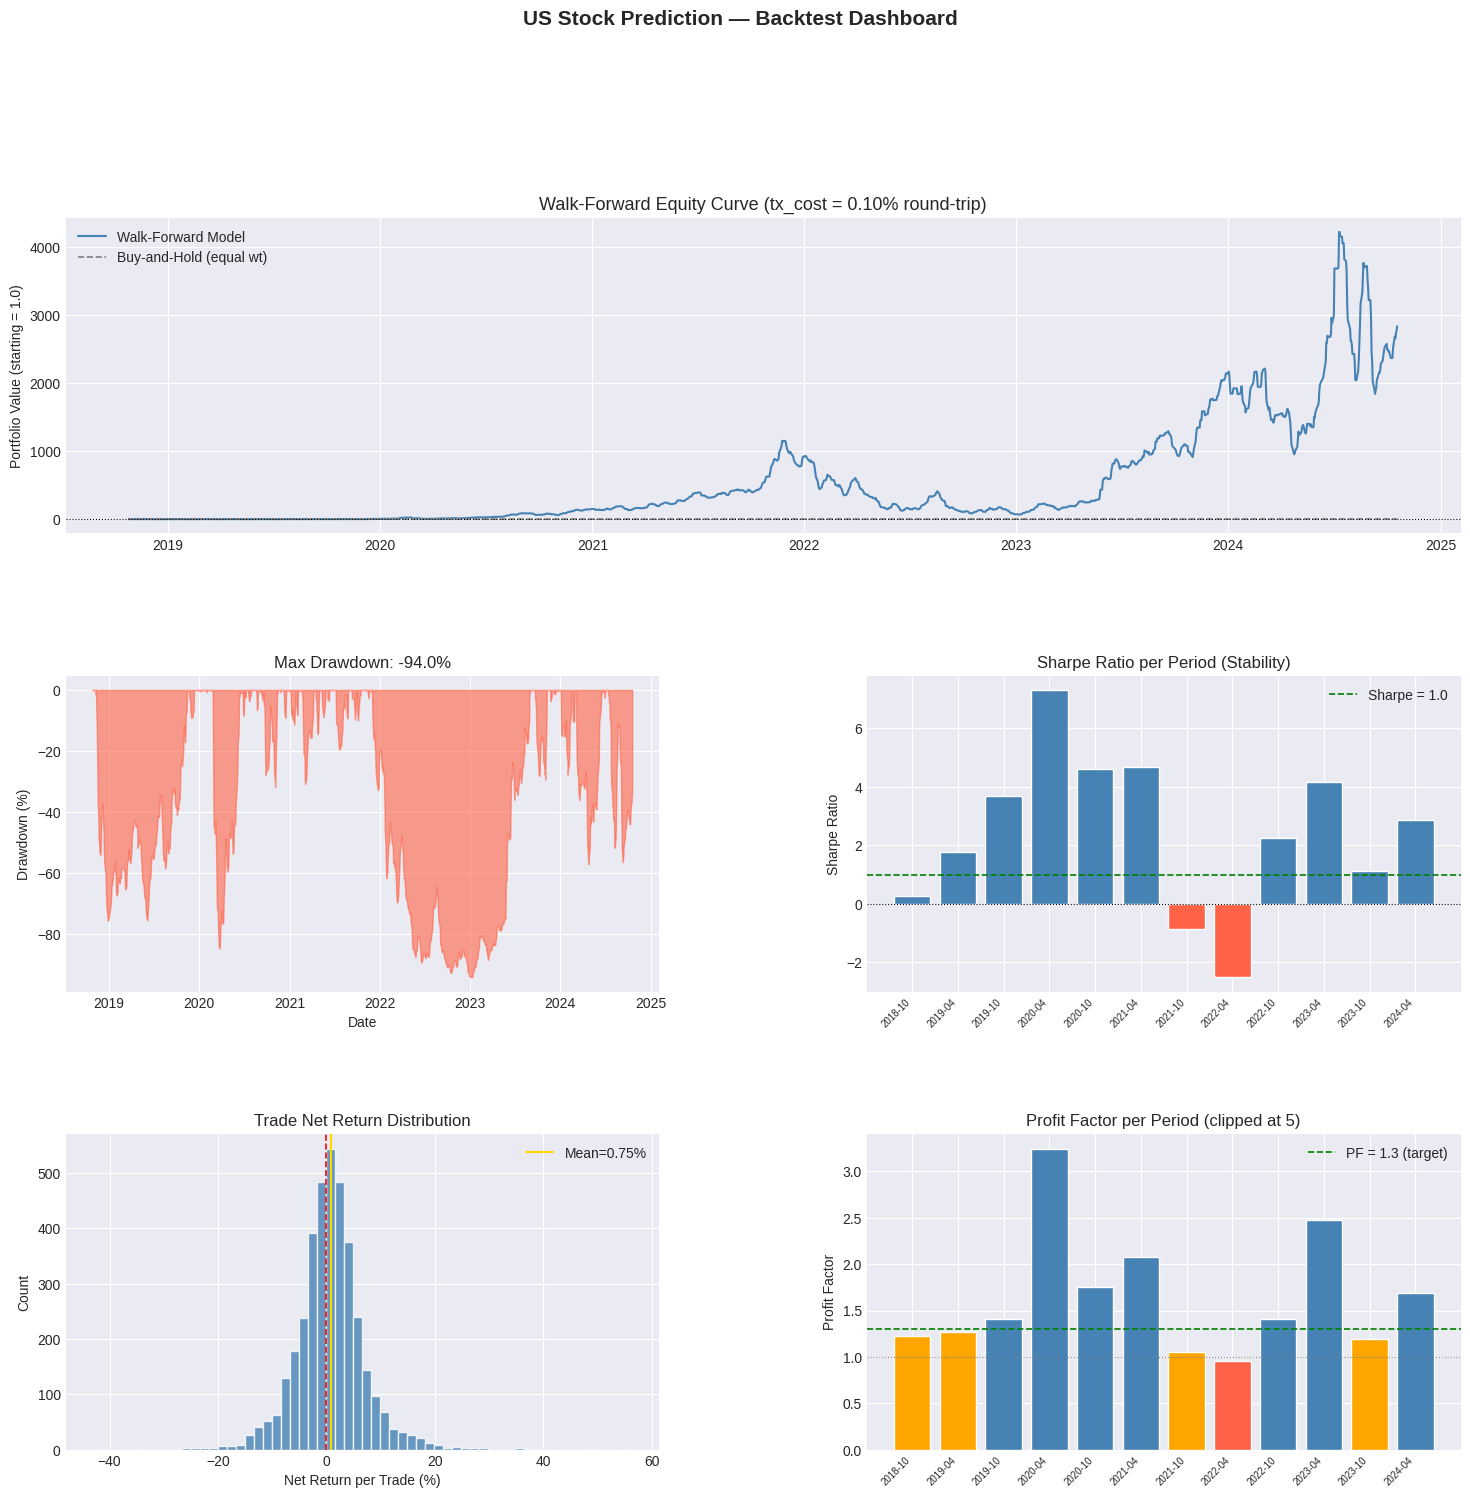

Saved: backtest_dashboard.png


In [8]:
fig = plt.figure(figsize=(18, 16))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── 1. Walk-forward equity curve ──────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
eq_wf = metrics_wf['_equity']
ax1.plot(eq_wf.index, eq_wf.values, color='steelblue', lw=1.5, label='Walk-Forward Model')

# buy-and-hold over same walk-forward window
wf_start = combined_wf['Date'].min()
wf_df_bah = df[df['Date'] >= wf_start].copy()
bah_daily = wf_df_bah.groupby('Date')['Close'].mean().pct_change().fillna(0)
bah_daily = bah_daily.reindex(eq_wf.index, fill_value=0)
bah_eq    = (1 + bah_daily).cumprod()
ax1.plot(bah_eq.index, bah_eq.values, color='gray', lw=1.2, linestyle='--', label='Buy-and-Hold (equal wt)')

ax1.axhline(1, color='black', lw=0.8, linestyle=':')
ax1.set_title('Walk-Forward Equity Curve (tx_cost = 0.10% round-trip)', fontsize=13)
ax1.set_ylabel('Portfolio Value (starting = 1.0)')
ax1.legend()

# ── 2. Drawdown ───────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
dd_wf = metrics_wf['_drawdown']
ax2.fill_between(dd_wf.index, dd_wf.values * 100, 0, color='tomato', alpha=0.6)
ax2.set_title(f'Max Drawdown: {metrics_wf["max_drawdown"]:.1%}', fontsize=12)
ax2.set_ylabel('Drawdown (%)')
ax2.set_xlabel('Date')

# ── 3. Sharpe per walk-forward period (stability) ─────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
colors = ['steelblue' if s > 0 else 'tomato' for s in wf_df['sharpe']]
bars = ax3.bar(range(len(wf_df)), wf_df['sharpe'], color=colors, edgecolor='white')
ax3.axhline(1.0, color='green',  lw=1.2, linestyle='--', label='Sharpe = 1.0')
ax3.axhline(0.0, color='black',  lw=0.8, linestyle=':')
ax3.set_xticks(range(len(wf_df)))
ax3.set_xticklabels(wf_df['period'], rotation=45, ha='right', fontsize=7)
ax3.set_title('Sharpe Ratio per Period (Stability)', fontsize=12)
ax3.set_ylabel('Sharpe Ratio')
ax3.legend()

# ── 4. Trade return distribution ──────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
r = trades_wf_all['net_return'] * 100
ax4.hist(r, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
ax4.axvline(0, color='red', lw=1.2, linestyle='--')
ax4.axvline(r.mean(), color='gold', lw=1.5, linestyle='-', label=f'Mean={r.mean():.2f}%')
ax4.set_title('Trade Net Return Distribution', fontsize=12)
ax4.set_xlabel('Net Return per Trade (%)')
ax4.set_ylabel('Count')
ax4.legend()

# ── 5. Profit Factor per period ───────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
pf_clipped = wf_df['profit_factor'].clip(upper=5)  # cap outliers for readability
colors_pf  = ['steelblue' if p >= 1.3 else 'orange' if p >= 1.0 else 'tomato'
               for p in pf_clipped]
ax5.bar(range(len(wf_df)), pf_clipped, color=colors_pf, edgecolor='white')
ax5.axhline(1.3, color='green', lw=1.2, linestyle='--', label='PF = 1.3 (target)')
ax5.axhline(1.0, color='gray',  lw=0.8, linestyle=':')
ax5.set_xticks(range(len(wf_df)))
ax5.set_xticklabels(wf_df['period'], rotation=45, ha='right', fontsize=7)
ax5.set_title('Profit Factor per Period (clipped at 5)', fontsize=12)
ax5.set_ylabel('Profit Factor')
ax5.legend()

plt.suptitle('US Stock Prediction — Backtest Dashboard', fontsize=15, fontweight='bold', y=1.01)
plt.savefig('backtest_dashboard.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: backtest_dashboard.png')

In [9]:
# ── Final Summary Table ───────────────────────────────────────────────────
print('\n' + '=' * 60)
print('FINAL SUMMARY')
print('=' * 60)

rows = []
for label, m in [('Baseline (train<2022)', metrics_base),
                 ('Walk-Forward Combined', metrics_wf)]:
    pf = f"{m['profit_factor']:.3f}" if m['profit_factor'] != np.inf else '∞'
    rows.append({
        'Strategy'      : label,
        'Trades'        : m['n_trades'],
        'Win Rate'      : f"{m['win_rate']:.1%}",
        'Profit Factor' : pf,
        'Sharpe'        : f"{m['sharpe_ratio']:.3f}",
        'Max DD'        : f"{m['max_drawdown']:.1%}",
        'CAGR'          : f"{m['cagr']:.1%}",
})

rows.append({
    'Strategy'      : 'Buy-and-Hold (test≥2022)',
    'Trades'        : 1,
    'Win Rate'      : '—',
    'Profit Factor' : '—',
    'Sharpe'        : '—',
    'Max DD'        : '—',
    'CAGR'          : f'{bah_cagr:.1%}',
})

summary_df = pd.DataFrame(rows).set_index('Strategy')
print(summary_df.to_string())

print('\n⚠  Profit Factor < 1.0 → ขาดทุนรวม  |  1.0–1.3 → marginal  |  > 1.3 → น่าใช้')
print('⚠  Sharpe < 0   → แย่กว่า risk-free  |  > 1.0 → น่าใช้งานจริง')
print('⚠  Walk-forward std(Sharpe) ต่ำ = stable   สูง = ดีแค่บางช่วง')


FINAL SUMMARY
                          Trades Win Rate Profit Factor Sharpe  Max DD    CAGR
Strategy                                                                      
Baseline (train<2022)       2099    55.0%         1.239  1.157  -92.0%   89.5%
Walk-Forward Combined       3748    56.1%         1.395  1.964  -94.0%  278.0%
Buy-and-Hold (test≥2022)       1        —             —      —       —   20.1%

⚠  Profit Factor < 1.0 → ขาดทุนรวม  |  1.0–1.3 → marginal  |  > 1.3 → น่าใช้
⚠  Sharpe < 0   → แย่กว่า risk-free  |  > 1.0 → น่าใช้งานจริง
⚠  Walk-forward std(Sharpe) ต่ำ = stable   สูง = ดีแค่บางช่วง
